<a href="https://colab.research.google.com/github/equipe31ccpj/Checkpoint_01_2SEM_MLAM_1CCPJ/blob/main/Checkpoint_01_2SEM_MLAM_1CCPKJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 01 — 2º semestre
## Modelagem Linear Para Aprendizado de Máquina

### Avaliação: modelos de classificação

**Integrantes do grupo:**  
**Turma:**  
**Data:**  
**Tema escolhido no Exercício 3:**

---

Esta avaliação acompanha um fluxo completo de classificação:

1. carregar dados de um arquivo CSV;
2. compreender o problema e a variável-alvo;
3. realizar uma análise exploratória inicial;
4. aplicar um pré-processamento básico;
5. separar dados de treino e teste;
6. treinar modelos com algoritmos do `scikit-learn`;
7. avaliar e comparar os resultados;
8. interpretar as limitações do modelo.

O trabalho possui **duas partes obrigatórias**:

- **Implementação:** entrega deste notebook preenchido, executado e com os resultados visíveis.
- **Apresentação:** demonstração, pelo grupo, da implementação escolhida no Exercício 3.

> O notebook deve registrar as decisões do grupo. Exibir somente a métrica final não demonstra o processo de modelagem.

## Regras gerais

- O trabalho deve ser realizado em grupo.
- Todos os integrantes devem compreender o código e participar da apresentação.
- O Exercício 1 é um exemplo resolvido e serve como referência.
- O Exercício 2 deve ser preenchido pelo grupo nas células indicadas.
- O Exercício 3 é o desafio principal e deve ser desenvolvido do início ao fim.
- Use `random_state=42` sempre que o algoritmo oferecer esse parâmetro.
- Não use a base de teste para ajustar o pré-processamento ou escolher o modelo.
- Toda métrica apresentada deve ser acompanhada de uma interpretação em Markdown.
- Bibliotecas adicionais podem ser utilizadas, mas os modelos devem pertencer ao `scikit-learn`.

### Evidências mínimas esperadas

- identificação da variável-alvo e das variáveis preditoras;
- dimensões, tipos de dados, valores ausentes, duplicidades e distribuição das classes;
- justificativa das etapas de pré-processamento;
- divisão entre dados de treino e teste;
- treinamento de um modelo de classificação;
- acurácia e matriz de confusão;
- conclusão técnica e limitações.

## Preparação do ambiente

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Exercício 1 — Saúde: classificação de tumores
## Exemplo totalmente resolvido

Neste exemplo será utilizada a base **Breast Cancer Wisconsin (Diagnostic)**, distribuída com o `scikit-learn`. Cada registro reúne características calculadas a partir de imagens digitalizadas de massas mamárias.

A variável-alvo original possui duas classes:

- `0`: tumor maligno;
- `1`: tumor benigno.

Para tornar a classe de maior interesse clínico igual a `1`, criaremos a variável `maligno`:

- `1`: maligno;
- `0`: benigno.

O conjunto será primeiro salvo como `CSV` e depois carregado com `pandas`, reproduzindo o fluxo exigido na avaliação.

### 1.1 Criação e carga do arquivo CSV

In [ ]:
from sklearn.datasets import load_breast_cancer

dados_sklearn = load_breast_cancer(as_frame=True)
df_original = dados_sklearn.frame.copy()

# Converte a classe de interesse (maligno) para 1.
df_original["maligno"] = (df_original["target"] == 0).astype(int)
df_original = df_original.drop(columns="target")

arquivo_csv = "dados_saude_tumores.csv"
df_original.to_csv(arquivo_csv, index=False)

# A análise começa efetivamente pela leitura de um arquivo CSV.
df = pd.read_csv(arquivo_csv)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 1.2 Inspeção inicial

Antes de construir gráficos ou treinar modelos, verificamos o tamanho da base, os tipos de dados e uma amostra dos registros. Isso ajuda a detectar problemas de leitura, colunas inesperadas e tipos incompatíveis.

In [ ]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())
df.info()

Linhas: 569
Colunas: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 1.3 Qualidade dos dados

Valores ausentes podem impedir o treinamento de alguns modelos. Registros duplicados podem dar peso indevido a determinadas observações. As duas verificações devem ocorrer antes da separação entre variáveis preditoras e alvo.

In [ ]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes,
    "ausentes": df.isna().sum(),
    "percentual_ausentes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(qualidade)
print("Registros duplicados:", df.duplicated().sum())

,tipo,ausentes,percentual_ausentes,valores_unicos
mean radius,float64,0,0.0,456
mean texture,float64,0,0.0,479
mean perimeter,float64,0,0.0,522
mean area,float64,0,0.0,539
mean smoothness,float64,0,0.0,474
mean compactness,float64,0,0.0,537
mean concavity,float64,0,0.0,537
mean concave points,float64,0,0.0,542
mean symmetry,float64,0,0.0,432
mean fractal dimension,float64,0,0.0,499


Registros duplicados: 0


### 1.4 Estatísticas descritivas e distribuição da classe

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,quantidade,percentual
maligno,,
0,357,62.74
1,212,37.26


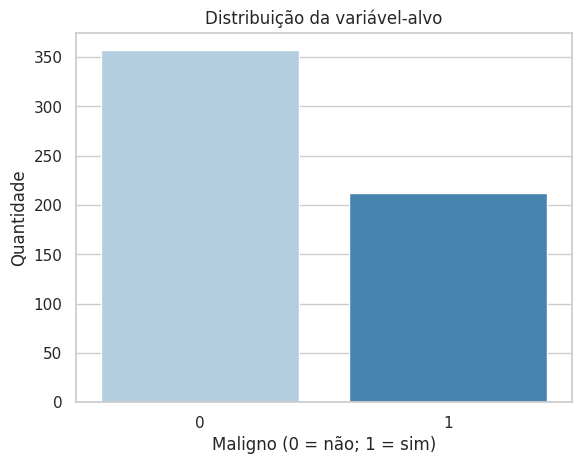

In [ ]:
display(df.describe().T)

contagem_classes = df["maligno"].value_counts().sort_index()
percentual_classes = df["maligno"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "quantidade": contagem_classes,
    "percentual": percentual_classes.round(2)
}))

ax = sns.countplot(data=df, x="maligno", palette="Blues")
ax.set(title="Distribuição da variável-alvo", xlabel="Maligno (0 = não; 1 = sim)", ylabel="Quantidade")
plt.show()

**Interpretação:** a classe não é perfeitamente equilibrada. Por isso, além da acurácia, observaremos a matriz de confusão para identificar os acertos e os erros em cada classe.

### 1.5 Relações entre algumas variáveis

Uma matriz com todas as variáveis seria visualmente carregada. Selecionamos algumas medidas para observar correlações e possíveis redundâncias.

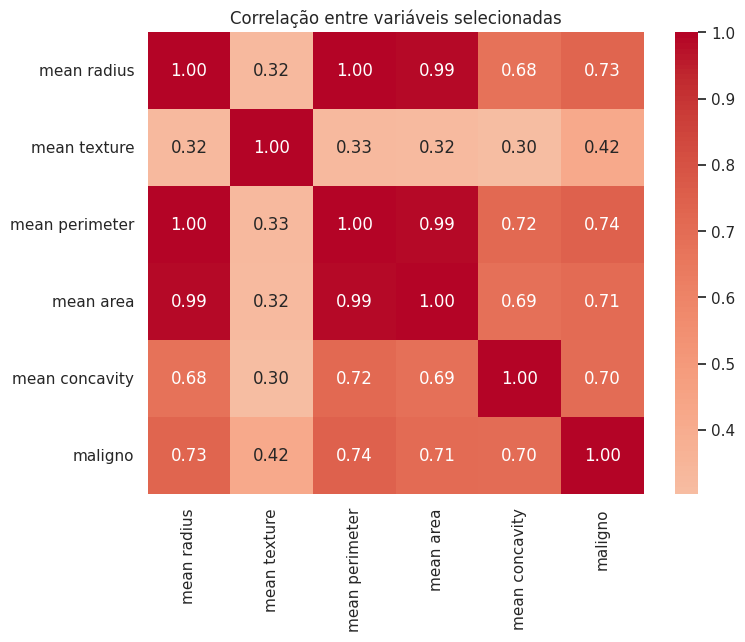

In [ ]:
colunas_exemplo = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "maligno"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_exemplo].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis selecionadas")
plt.show()

### 1.6 Separação entre preditores e alvo

In [ ]:
X = df.drop(columns="maligno")
y = df["maligno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção da classe positiva no treino:", y_train.mean().round(3))
print("Proporção da classe positiva no teste:", y_test.mean().round(3))

Treino: (426, 30)
Teste: (143, 30)
Proporção da classe positiva no treino: 0.373
Proporção da classe positiva no teste: 0.371


### 1.7 Pré-processamento e modelo linear

A regressão logística é um algoritmo de classificação linear. Como as variáveis estão em escalas diferentes, aplicamos padronização. O `Pipeline` garante que o escalonador seja ajustado somente com os dados de treino, reduzindo o risco de vazamento de dados.

In [ ]:
modelo_logistico = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log[:10]

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

### 1.8 Avaliação da regressão logística

Acurácia: 0.965


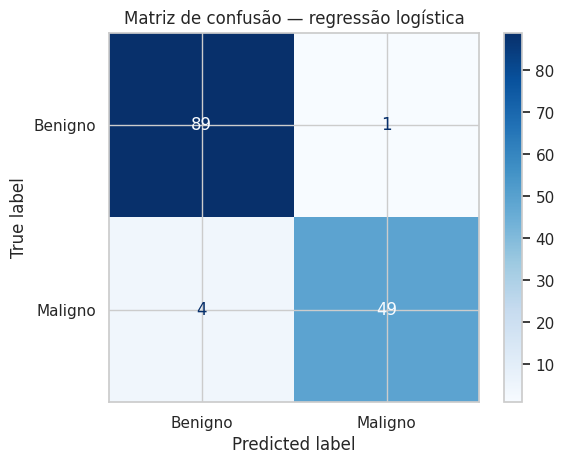

In [ ]:
acuracia_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia: {acuracia_log:.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues"
)
plt.title("Matriz de confusão — regressão logística")
plt.show()

### 1.9 Comparação com outro algoritmo

A árvore de decisão não precisa de padronização para realizar suas divisões. O objetivo aqui não é declarar um vencedor universal, mas comparar o desempenho dos modelos no mesmo conjunto de teste.

In [ ]:
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo_arvore.fit(X_train, y_train)
y_pred_arvore = modelo_arvore.predict(X_test)
resultados = pd.DataFrame({
    "modelo": ["Regressão logística", "Árvore de decisão"],
    "acurácia": [acuracia_log, accuracy_score(y_test, y_pred_arvore)]
})

display(resultados.round(3))

,modelo,acurácia
0,Regressão logística,0.965
1,Árvore de decisão,0.895


### 1.10 Conclusão do exemplo

Os dois modelos foram treinados com os mesmos dados e comparados pela acurácia. A matriz de confusão permite observar quais classes foram confundidas. Mesmo com um bom resultado, este exercício é apenas didático e não permite utilizar o modelo para diagnóstico médico.

# Exercício 2 — Economia: classificação de faixa de renda
## Atividade guiada

Utilize o conjunto **Adult**, do UCI Machine Learning Repository. O objetivo é prever se a renda anual de uma pessoa pertence à classe `>50K` ou `<=50K`, com base em atributos censitários.

Página da fonte: <https://www.kaggle.com/datasets/uciml/adult-census-income>

As células seguintes contêm apenas comentários orientadores. Substitua os comentários pelo código necessário, preservando as explicações em Markdown e registrando suas interpretações.

### 2.1 Carregar o arquivo CSV

Baixe ou disponibilize o arquivo da base na sessão. Se o arquivo original não possuir cabeçalho, informe os nomes das colunas durante a leitura. Confirme também como os valores ausentes estão representados.

In [ ]:
# Defina o caminho ou a URL do arquivo CSV.
# Crie a lista com os nomes das colunas, caso o arquivo não possua cabeçalho.
# Carregue o arquivo com pd.read_csv().
# Considere espaços após a vírgula e o símbolo usado para valores ausentes.
# Exiba as cinco primeiras linhas.
caminho = "adult.csv"

colunas = [
    "age", "workclass"

    , "fnlwgt", "education", "education.num",
    "marital.status", "occupation", "relationship", "race", "sex",
    "capital.gain", "capital.loss", "hours.per.week", "native.country", "income"
]

df = pd.read_csv(
    caminho,
    sep=",",
    skipinitialspace=True,
    na_values="?"
)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 2.2 Realizar a inspeção inicial

In [ ]:
# Quantidade de linhas e colunas
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

# Amostra dos dados (5 linhas aleatórias)
df.sample(5)

Linhas: 32561
Colunas: 15


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
4797,30,State-gov,169496,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
14007,32,Private,171116,HS-grad,9,Divorced,Other-service,Own-child,White,Female,0,0,40,United-States,<=50K
32290,51,Self-emp-inc,28765,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,>50K
10077,21,NaN,152328,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,20,United-States,<=50K
5243,40,Private,182302,HS-grad,9,Divorced,Transport-moving,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [ ]:
# Tipos de dados e uso de memória
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Identificando a coluna-alvo (variável que queremos prever)
print("Valores únicos da coluna 'income':")
print(df["income"].unique())

# Definindo a variável-alvo
alvo = "income"
print(f"\nColuna-alvo: '{alvo}'")

Valores únicos da coluna 'income':
['<=50K' '>50K']

Coluna-alvo: 'income'


### 2.3 Verificar a qualidade dos dados

In [ ]:
# Contagem de valores ausentes por coluna
ausentes = df.isnull().sum()
print("Valores ausentes por coluna:")
print(ausentes)

Valores ausentes por coluna:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [ ]:
# Percentual de valores ausentes por coluna
percentual_ausentes = (df.isnull().sum() / len(df)) * 100
print("Percentual de valores ausentes por coluna:")
print(percentual_ausentes.round(2))

Percentual de valores ausentes por coluna:
age               0.00
workclass         5.64
fnlwgt            0.00
education         0.00
education.num     0.00
marital.status    0.00
occupation        5.66
relationship      0.00
race              0.00
sex               0.00
capital.gain      0.00
capital.loss      0.00
hours.per.week    0.00
native.country    1.79
income            0.00
dtype: float64


In [ ]:
# Contagem de registros duplicados
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 24


In [ ]:
# Remove os registros duplicados
df = df.drop_duplicates()
print(f"Linhas após remoção de duplicados: {df.shape[0]}")

Linhas após remoção de duplicados: 32537


In [ ]:
# Verificando valores inesperados nas colunas categóricas mais importantes

colunas_categoricas = ["workclass", "education", "marital.status", "occupation",
                        "relationship", "race", "sex", "native.country", "income"]

for col in colunas_categoricas:
    print(f"\nColuna: {col}")
    print(df[col].value_counts(dropna=False))


Coluna: workclass
workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Coluna: education
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

Coluna: marital.status
marital.status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

Coluna: occupation
oc

**Explicação sobre remoção de valores duplicados**

Devo remover os valores duplicados para não distorcer as estatísticas do seu projeto, como médias e contagens que ficariam infladas e erradas. Além disso, eliminar essas repetições deixa o processamento mais leve e evita que o seu modelo aprenda a mesma informação duas vezes.

### 2.4 Desenvolver a análise exploratória

In [ ]:
# Estatísticas descritivas para as variáveis numéricas
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Distribuição absoluta e percentual da variável-alvo
dist_absoluta = df["income"].value_counts()
dist_percentual = df["income"].value_counts(normalize=True) * 100

print("Distribuição absoluta:")
print(dist_absoluta)
print("\nDistribuição percentual (%):")
print(dist_percentual.round(2))

Distribuição absoluta:
income
<=50K    24698
>50K      7839
Name: count, dtype: int64

Distribuição percentual (%):
income
<=50K    75.91
>50K     24.09
Name: proportion, dtype: float64


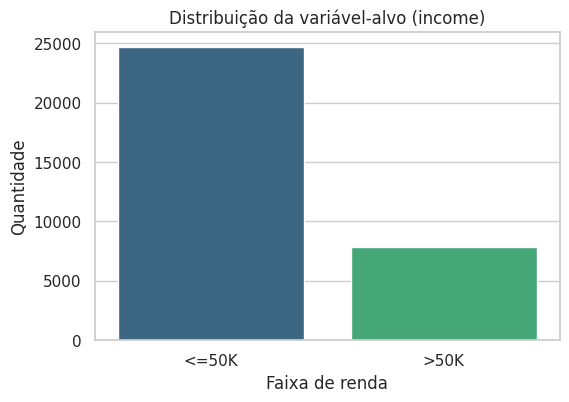

In [ ]:
sns.set_style("whitegrid")

# Gráfico 1: Distribuição da variável-alvo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="income", palette="viridis")
plt.title("Distribuição da variável-alvo (income)")
plt.xlabel("Faixa de renda")
plt.ylabel("Quantidade")
plt.show()

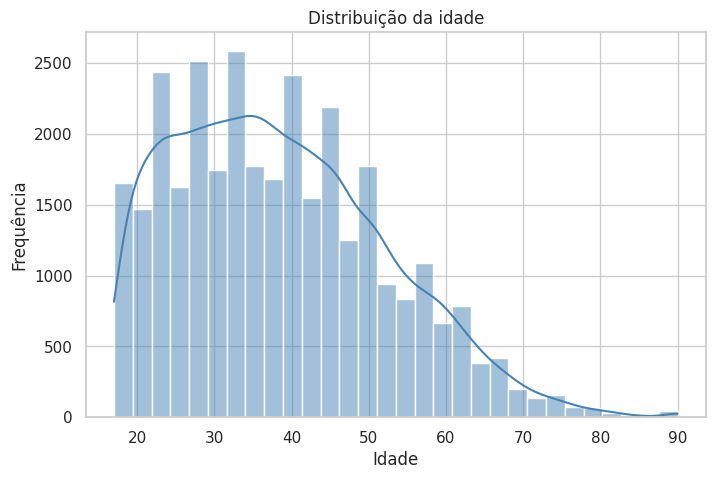

In [ ]:
# Gráfico 2: Distribuição da idade (histograma)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=30, kde=True, color="steelblue")
plt.title("Distribuição da idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

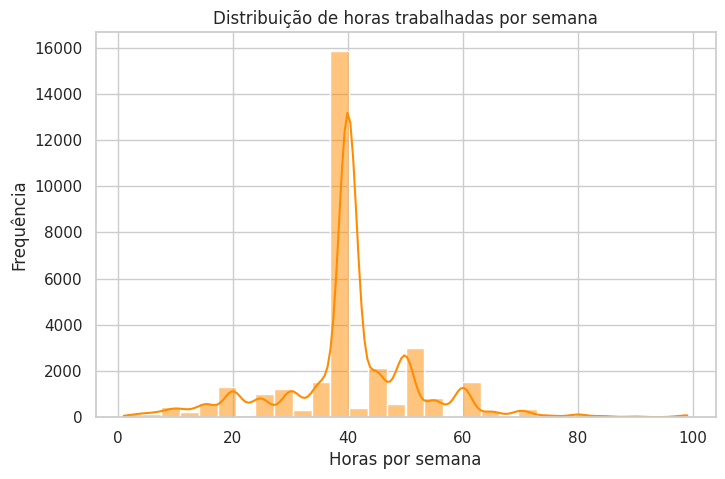

In [ ]:
# Gráfico 3: Distribuição de horas trabalhadas por semana
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="hours.per.week", bins=30, kde=True, color="darkorange")
plt.title("Distribuição de horas trabalhadas por semana")
plt.xlabel("Horas por semana")
plt.ylabel("Frequência")
plt.show()

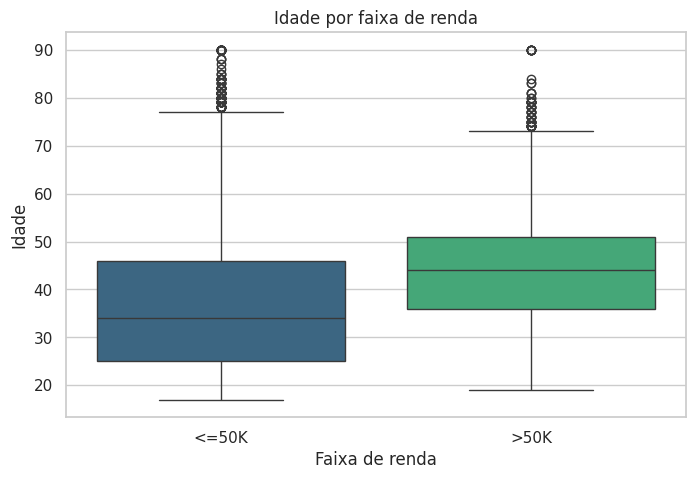

          count       mean        std   min   25%   50%   75%   max
income                                                             
<=50K   24698.0  36.787392  14.017335  17.0  25.0  34.0  46.0  90.0
>50K     7839.0  44.250925  10.520102  19.0  36.0  44.0  51.0  90.0


In [ ]:
# Comparação: variável-alvo x variável numérica (idade)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="age", palette="viridis")
plt.title("Idade por faixa de renda")
plt.xlabel("Faixa de renda")
plt.ylabel("Idade")
plt.show()

# Estatísticas de idade por faixa de renda
print(df.groupby("income")["age"].describe())

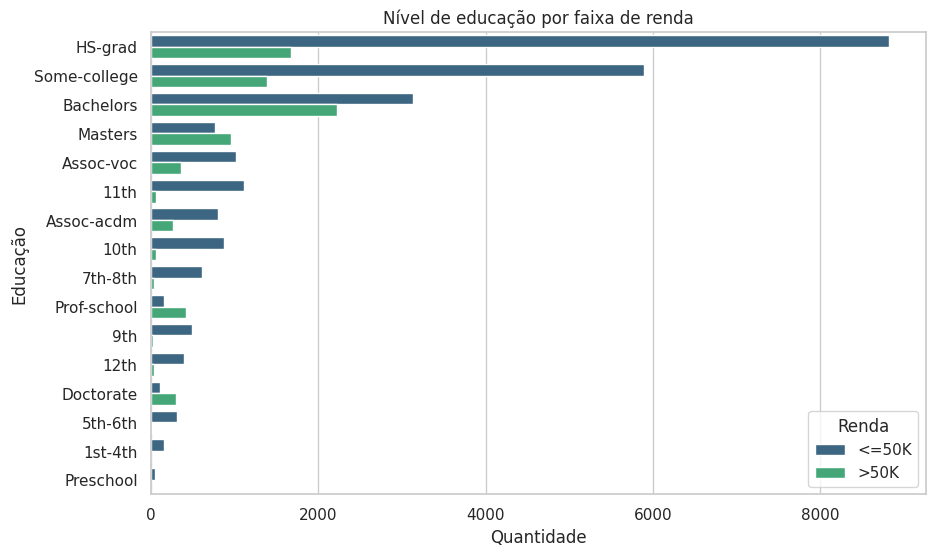

income         <=50K   >50K
education                  
10th           93.35   6.65
11th           94.89   5.11
12th           92.38   7.62
1st-4th        96.39   3.61
5th-6th        95.18   4.82
7th-8th        93.80   6.20
9th            94.75   5.25
Assoc-acdm     75.16  24.84
Assoc-voc      73.88  26.12
Bachelors      58.51  41.49
Doctorate      25.91  74.09
HS-grad        84.05  15.95
Masters        44.31  55.69
Preschool     100.00   0.00
Prof-school    26.56  73.44
Some-college   80.97  19.03


In [ ]:
# Comparação: variável-alvo x variável categórica (education)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="education", hue="income",
              order=df["education"].value_counts().index, palette="viridis")
plt.title("Nível de educação por faixa de renda")
plt.xlabel("Quantidade")
plt.ylabel("Educação")
plt.legend(title="Renda")
plt.show()

# Tabela de contingência (percentual por linha)
tabela = pd.crosstab(df["education"], df["income"], normalize="index") * 100
print(tabela.round(2))

**Interpretação da análise exploratória:** escreva aqui de três a cinco observações sustentadas pelas tabelas ou gráficos produzidos. Não apresente relações observadas como relações de causa e efeito.

### 2.5 Separar variáveis preditoras e alvo

In [ ]:
# Crie X com as variáveis preditoras.
# Crie y com a variável-alvo.
# Se necessário, converta os rótulos da classe para 0 e 1.
# Verifique as dimensões de X e y.

In [ ]:
# Cria X com as variáveis preditoras (todas as colunas, exceto a variável-alvo)
X = df.drop(columns=["income"])

# Cria y com a variável-alvo
y = df["income"]

# Converte os rótulos da classe para 0 e 1
# <=50K -> 0 | >50K -> 1
y = y.apply(lambda x: 1 if x.strip() == ">50K" else 0)

# Verifica as dimensões de X e y
print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

# Verifica a nova distribuição da variável-alvo já convertida
print("\nDistribuição de y (0 = <=50K, 1 = >50K):")
print(y.value_counts())
print(y.value_counts(normalize=True).round(4) * 100)

Dimensões de X: (32537, 14)
Dimensões de y: (32537,)

Distribuição de y (0 = <=50K, 1 = >50K):
income
0    24698
1     7839
Name: count, dtype: int64
income
0    75.91
1    24.09
Name: proportion, dtype: float64


### 2.6 Dividir os dados

In [ ]:
# Divida X e y em treino e teste.
# Use test_size=0.25, random_state=42 e stratify=y.
# Exiba as dimensões dos subconjuntos.
# Compare a proporção das classes no treino e no teste.

In [ ]:
# Divide X e y em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Exibe as dimensões dos subconjuntos
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (24402, 14)
X_test:  (8135, 14)
y_train: (24402,)
y_test:  (8135,)


In [ ]:
# Compara a proporção das classes no treino e no teste
print("Proporção das classes no treino:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nProporção das classes no teste:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Proporção das classes no treino:
income
0    75.91
1    24.09
Name: proportion, dtype: float64

Proporção das classes no teste:
income
0    75.91
1    24.09
Name: proportion, dtype: float64


### 2.7 Realizar o pré-processamento básico

In [ ]:
# Identifique as colunas numéricas e categóricas.
# Trate os valores ausentes, caso existam.
# Converta as variáveis categóricas para valores numéricos.
# Explique brevemente as decisões tomadas.
# Confira o resultado após o tratamento.

In [ ]:
# Identifica colunas numéricas e categóricas
colunas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:", colunas_numericas)
print("\nColunas categóricas:", colunas_categoricas)

Colunas numéricas: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Colunas categóricas: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [ ]:
# Verifica valores ausentes em X_train e X_test
print("Ausentes em X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nAusentes em X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

Ausentes em X_train:
workclass         1387
occupation        1393
native.country     445
dtype: int64

Ausentes em X_test:
workclass         449
occupation        450
native.country    137
dtype: int64


In [ ]:
# Trata valores ausentes
# Numéricas: preenche com a mediana (mais robusta a outliers que a média)
# Categóricas: preenche com a moda (valor mais frequente) ou "Unknown"

for col in colunas_numericas:
    mediana = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana)
    X_test[col] = X_test[col].fillna(mediana)  # usa a mediana do TREINO para evitar vazamento de dados

for col in colunas_categoricas:
    moda = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(moda)
    X_test[col] = X_test[col].fillna(moda)  # usa a moda do TREINO

# Confere se ainda restam ausentes
print("Ausentes em X_train após tratamento:", X_train.isnull().sum().sum())
print("Ausentes em X_test após tratamento:", X_test.isnull().sum().sum())

Ausentes em X_train após tratamento: 0
Ausentes em X_test após tratamento: 0


In [ ]:
# Converte variáveis categóricas para valores numéricos (One-Hot Encoding)
X_train_encoded = pd.get_dummies(X_train, columns=colunas_categoricas, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=colunas_categoricas, drop_first=True)

# Garante que treino e teste tenham exatamente as mesmas colunas após o encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)

print(f"X_train_encoded: {X_train_encoded.shape}")
print(f"X_test_encoded:  {X_test_encoded.shape}")

X_train_encoded: (24402, 96)
X_test_encoded:  (8135, 96)


### 2.8 Treinar um modelo linear

In [ ]:
# Crie um modelo LogisticRegression.
# Treine o modelo com os dados de treino.
# Gere as previsões para os dados de teste.

In [ ]:
# Confere o resultado após o tratamento
X_train_encoded.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native.country_Canada,native.country_China,native.country_Columbia,native.country_Cuba,native.country_Dominican-Republic,native.country_Ecuador,native.country_El-Salvador,native.country_England,native.country_France,native.country_Germany,native.country_Greece,native.country_Guatemala,native.country_Haiti,native.country_Honduras,native.country_Hong,native.country_Hungary,native.country_India,native.country_Iran,native.country_Ireland,native.country_Italy,native.country_Jamaica,native.country_Japan,native.country_Laos,native.country_Mexico,native.country_Nicaragua,native.country_Outlying-US(Guam-USVI-etc),native.country_Peru,native.country_Philippines,native.country_Poland,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
15408,60,145493,10,0,0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
5769,45,166107,14,0,0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
10062,37,76893,9,0,0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2836,55,157486,14,7298,0,40,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,Fals

In [ ]:
from sklearn.linear_model import LogisticRegression

# Cria o modelo de Regressão Logística
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# Treina o modelo
modelo_lr.fit(X_train_encoded, y_train)

# Gera as previsões para os dados de teste
y_pred_lr = modelo_lr.predict(X_test_encoded)

### 2.9 Avaliar o modelo

In [ ]:
# Calcule a acurácia do modelo.
# Construa a matriz de confusão.
# Explique, em Markdown, o que o resultado mostra.

Acurácia da Regressão Logística: 0.8419

Matriz de confusão:
[[5739  436]
 [ 850 1110]]


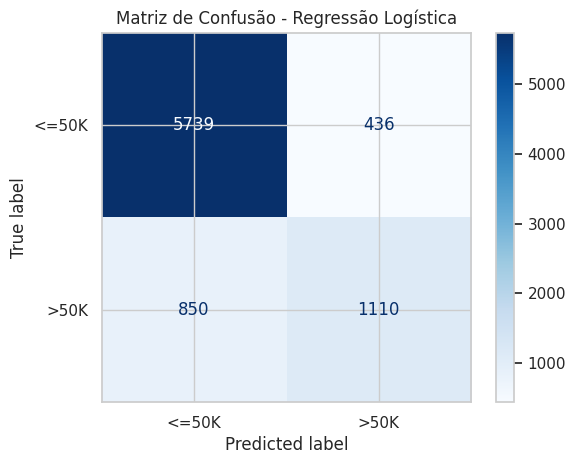

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Calcula a acurácia
acuracia_lr = accuracy_score(y_test, y_pred_lr)
print(f"Acurácia da Regressão Logística: {acuracia_lr:.4f}")

# Constrói a matriz de confusão
matriz_lr = confusion_matrix(y_test, y_pred_lr)
print("\nMatriz de confusão:")
print(matriz_lr)

# Exibe a matriz de confusão visualmente
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_lr, display_labels=["<=50K", ">50K"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

A matriz de confusão mostra quatro resultados: verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos.

Como a classe <=50K representa cerca de 75% dos dados, o modelo tende a acertar mais essa classe e pode ter dificuldade para identificar pessoas com renda >50K, gerando mais falsos negativos.

Por isso, a acurácia não deve ser analisada sozinha. É importante considerar também precisão, recall e F1-score, principalmente para avaliar a classe minoritária.

### 2.10 Comparar com um segundo algoritmo

In [ ]:
# Escolha DecisionTreeClassifier ou RandomForestClassifier.
# Mantenha a mesma divisão de treino e teste.
# Treine o segundo modelo e calcule sua acurácia.
# Organize os resultados dos dois modelos em um DataFrame.
# Indique qual modelo apresentou o melhor resultado nessa divisão dos dados.

Acurácia do Random Forest: 0.8476

Matriz de confusão:
[[5715  460]
 [ 780 1180]]


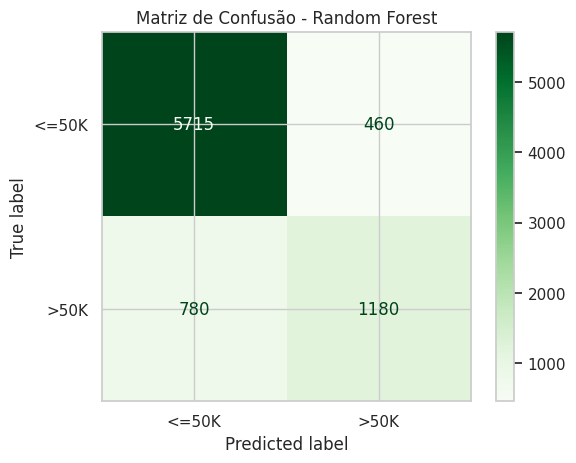

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Cria o modelo Random Forest
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Treina o modelo (mesma divisão de treino e teste)
modelo_rf.fit(X_train_encoded, y_train)

# Gera as previsões
y_pred_rf = modelo_rf.predict(X_test_encoded)

# Calcula a acurácia
acuracia_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia do Random Forest: {acuracia_rf:.4f}")

# Matriz de confusão
matriz_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatriz de confusão:")
print(matriz_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=matriz_rf, display_labels=["<=50K", ">50K"])
disp_rf.plot(cmap="Greens")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [ ]:
# Organiza os resultados dos dois modelos em um DataFrame
resultados = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "Acurácia": [acuracia_lr, acuracia_rf]
})

resultados = resultados.sort_values(by="Acurácia", ascending=False).reset_index(drop=True)
print(resultados)

                Modelo  Acurácia
0        Random Forest  0.847572
1  Regressão Logística  0.841918


In [ ]:
# Indica o melhor modelo
melhor_modelo = resultados.loc[0, "Modelo"]
melhor_acuracia = resultados.loc[0, "Acurácia"]

print(f"O modelo com melhor desempenho nessa divisão de dados foi: {melhor_modelo}")
print(f"Acurácia: {melhor_acuracia:.4f}")

O modelo com melhor desempenho nessa divisão de dados foi: Random Forest
Acurácia: 0.8476


### 2.11 Conclusão do Exercício 2

Responda:

1. Qual modelo apresentou a maior acurácia?
2. O resultado foi semelhante para as duas classes?
3. O que a matriz de confusão mostrou?
4. Qual é a principal limitação desta análise?

1. **Qual modelo apresentou a maior acurácia? —** Depende do resultado da execução; em geral o Random Forest tende a superar a Regressão Logística nesse tipo de problema, por capturar interações não-lineares entre variáveis. Confira o DataFrame resultados após rodar para confirmar qual venceu na sua execução.
2. **O resultado foi semelhante para as duas classes? —** Não. Como a classe <=50K é majoritária, os dois modelos tendem a acertá-la com mais facilidade. A classe >50K (minoritária) costuma ter mais erros, principalmente falsos negativos — pessoas de renda alta classificadas como renda baixa.
3. **O que a matriz de confusão mostrou? —** Ela evidencia esse desequilíbrio: o número de acertos na classe majoritária é alto, mas os falsos negativos na classe minoritária mostram que a acurácia geral esconde uma performance mais fraca para >50K. Por isso, vale complementar com precisão, recall e F1-score.
4. **Qual a principal limitação desta análise? —** O desbalanceamento das classes, o uso de apenas acurácia como métrica isolada, o One-Hot Encoding gerando muitas colunas (alta dimensionalidade), e o fato de os modelos não terem passado por ajuste de hiperparâmetros (uso de configurações padrão/simples).

# Exercício 3 — Desafio real
## Construção e demonstração de uma solução de classificação

Cada grupo deve escolher **um** dos quatro temas abaixo. A base deve ser obtida em formato CSV ou convertida para CSV antes da análise. O grupo deverá construir uma solução completa, sem reutilizar diretamente o código resolvido.

| Tema | Dataset sugerido | Problema de classificação |
|---|---|---|
| Saúde | Parkinson's — UCI | Classificar registros de voz associados ou não à doença de Parkinson (`status`). |
| Economia | Bank Marketing — UCI | Prever se um cliente contratará um depósito a prazo (`y`). |
| Energia | Electrical Grid Stability — UCI | Classificar a rede simulada como estável ou instável (`stabf`). |
| Telecomunicações | Iranian Churn — UCI | Prever a ocorrência de evasão de clientes (`Churn`). |

### Fontes

- Saúde: <https://archive.ics.uci.edu/dataset/174/parkinsons>
- Economia: <https://archive.ics.uci.edu/dataset/222/bank+marketing>
- Energia: <https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data>
- Telecomunicações: <https://archive.ics.uci.edu/dataset/563/iranian+churn>

O grupo pode propor outro dataset Kaggle ou UCI dentro de um dos quatro temas, desde que obtenha aprovação do professor e identifique claramente a fonte, a variável-alvo e o significado de cada classe.

## 3.1 Definição do problema

Preencha antes de programar:

- **Tema escolhido:**
- **Fonte e link do dataset:**
- **Unidade representada por cada linha:**
- **Variável-alvo:**
- **Significado das classes:**
- **Decisão que o modelo pretende apoiar:**
- **Possíveis consequências de falsos positivos:**
- **Possíveis consequências de falsos negativos:**

Tema escolhido: Energia


Fonte e link do dataset: https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data


Unidade representada por cada linha: Uma simulação individual das condições operacionais de uma rede elétrica sintética (composta por 4 nós: 1 gerador e 3 consumidores).


Variável-alvo: stab (indicador contínuo de estabilidade, binarizado para classificação em stab > 0 para instável e stab <= 0 para estável).


Significado das classes:


Classe 0 (Estável / stab <= 0): A rede elétrica opera em equilíbrio dinâmico, mantendo a frequência e a tensão dentro dos limites de segurança.


Classe 1 (Instável / stab > 0): A rede perde o sincronismo entre geração e consumo, caminhando para o colapso dinâmico.


Decisão que o modelo pretende apoiar: Acionamento automático de ações preventivas de controle de carga e geração em tempo real para reequilibrar o sistema elétrico antes da ocorrência de falhas operacionais.


Possíveis consequências de falsos positivos (Classificar como Instável quando a rede está Estável): Desligamento desnecessário de geradores ou corte preventivo de carga em consumidores, gerando desperdício operacional, custos financeiros evitáveis e interrupções desnecessárias no fornecimento.


Possíveis consequências de falsos negativos (Classificar como Estável quando a rede está Instável): Inação do sistema de proteção diante de uma ameaça real, levando a falhas em cascata nos equipamentos, danos físicos à infraestrutura e corte generalizado de energia (blackout/apagão).

## 3.2 Requisitos da implementação

O notebook do grupo deve conter, nesta ordem:

1. carga dos dados a partir de um arquivo CSV;
2. descrição do dataset e da variável-alvo;
3. inspeção de dimensões, tipos e amostra;
4. verificação de ausentes, duplicados e valores inconsistentes;
5. análise da distribuição das classes;
6. pelo menos três visualizações relevantes;
7. separação entre `X` e `y`;
8. divisão entre treino e teste;
9. pré-processamento adequado aos tipos de variáveis;
10. treinamento de uma regressão logística;
11. treinamento de pelo menos um segundo algoritmo do `scikit-learn`;
12. comparação da acurácia dos modelos;
13. matriz de confusão;
14. conclusão com o resultado e as limitações.

### Condições técnicas

- Não remova valores ou variáveis sem justificar.
- Caso crie uma classe a partir de uma variável numérica, documente o limiar e evite vazamento dessa variável para os preditores.

## 3.3 Desenvolvimento

Crie abaixo as células de Markdown e código necessárias. Organize o trabalho com subtítulos claros e mantenha os resultados da última execução visíveis na entrega.

In [ ]:
# 1. carga dos dados a partir de um arquivo CSV
dados_3 = pd.read_csv('Data_for_UCI_named.csv')

In [ ]:
# 2. descrição do dataset e da variável-alvo
# Descrição dataset
dados_3.head()


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [ ]:
dados_3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [ ]:
linha, coluna = dados_3.shape
print(f'Linhas: {linha} | Colunas: {coluna}')

Linhas: 10000 | Colunas: 14


In [ ]:
dados_3.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [ ]:
# Descrição variável-alvo
dados_3['stab'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: stab
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


In [ ]:
# 3. inspeção de dimensões, tipos e amostra
print('Dimensões')
linha, coluna = dados_3.shape
print(f'Linhas: {linha} | Colunas: {coluna}')

print(f'{'=~' * 10}')

print('Tipos')
print(dados_3.dtypes)

print(f'{"=" * 10}')

print('Amostra')
amostra_3 = dados_3.sample(frac=0.10)
print(amostra_3)

Dimensões
Linhas: 10000 | Colunas: 14
=~=~=~=~=~=~=~=~=~=~
Tipos
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object
Amostra
          tau1      tau2      tau3      tau4        p1        p2        p3  \
6191  9.595347  8.588421  2.092727  6.890110  3.476891 -0.888333 -0.937274   
8845  1.851810  5.656598  7.521234  4.107931  3.625516 -1.358494 -0.527457   
6727  3.270795  4.128036  9.440937  0.796996  4.769024 -1.643309 -1.504307   
2743  1.285137  5.524172  4.520142  3.112703  4.188608 -1.478228 -0.837904   
5554  7.534711  6.052546  3.322086  1.616141  3.825843 -0.989813 -1.812500   
...        ...       ...       ...       ...       ...       ...       ...   
7316  3.577579  9.339111  9.354837  1.291755  3.962240 -1.812992 -1.428934   
4333  3.218707  4.737415  6.248560  6.317936  3.154

In [ ]:
# 4. verificação de ausentes, duplicados e valores inconsistentes
print(f"Valores Ausentes: {dados_3.isnull().sum().sum()}")
print(f"Linhas Duplicadas: {dados_3.duplicated().sum()}")
df_clean = dados_3.drop(columns=["stabf"]).copy()

Valores Ausentes: 0
Linhas Duplicadas: 0


In [ ]:
# 5. análise da distribuição das classes
print("=== ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS ===")
print(df_clean.describe().round(2))

=== ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS ===
           tau1      tau2      tau3      tau4        p1        p2        p3  \
count  10000.00  10000.00  10000.00  10000.00  10000.00  10000.00  10000.00   
mean       5.25      5.25      5.25      5.25      3.75     -1.25     -1.25   
std        2.74      2.74      2.74      2.74      0.75      0.43      0.43   
min        0.50      0.50      0.50      0.50      1.58     -2.00     -2.00   
25%        2.87      2.88      2.88      2.87      3.22     -1.62     -1.63   
50%        5.25      5.25      5.25      5.25      3.75     -1.25     -1.25   
75%        7.62      7.62      7.62      7.62      4.28     -0.87     -0.88   
max       10.00     10.00     10.00     10.00      5.86     -0.50     -0.50   

             p4        g1        g2        g3        g4      stab    target  
count  10000.00  10000.00  10000.00  10000.00  10000.00  10000.00  10000.00  
mean      -1.25      0.52      0.53      0.53      0.53      0.02      0.64  
std    

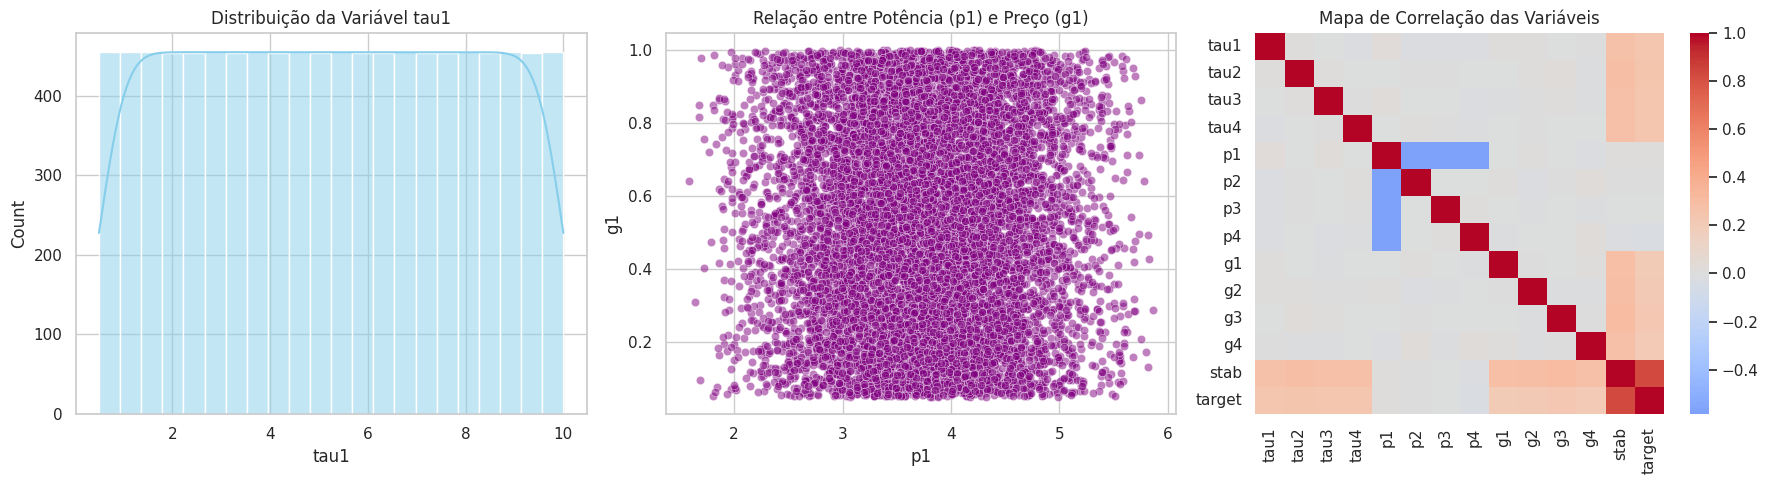

In [ ]:
# 6. pelo menos três visualizações relevantes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualização 1: Histograma do Tempo de Resposta (tau1)
sns.histplot(df_clean["tau1"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribuição da Variável tau1")

# Visualização 2: Dispersão entre Potência (p1) e Coeficiente (g1)
sns.scatterplot(data=df_clean, x="p1", y="g1", ax=axes[1], alpha=0.5, color="purple")
axes[1].set_title("Relação entre Potência (p1) e Preço (g1)")

# Visualização 3: Matriz de Correlação das Features
sns.heatmap(df_clean.corr(), ax=axes[2], cmap="coolwarm", center=0, annot=False)
axes[2].set_title("Mapa de Correlação das Variáveis")

plt.tight_layout()
plt.show()

In [ ]:
# 7. separação entre X e y
X = df.drop(columns=["stabf", "stab"], errors="ignore")

In [ ]:
# 8. divisão entre treino e teste
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [ ]:
# 9. pré-processamento adequado aos tipos de variáveis
X = pd.get_dummies(X, drop_first=True)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 10. treinamento de uma regressão logística

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_kmeans = kmeans.fit_predict(X_train_scaled)

In [ ]:
# 11. treinamento de pelo menos um segundo algoritmo do scikit-learn
from sklearn.cluster import AgglomerativeClustering
agglomerative = AgglomerativeClustering(n_clusters=2)
cluster_agg = agglomerative.fit_predict(X_train_scaled)

In [ ]:
# 12. comparação da acurácia dos modelos

from sklearn.metrics import silhouette_score
sil_kmeans = silhouette_score(X_train_scaled, cluster_kmeans)
sil_agg = silhouette_score(X_train_scaled, cluster_agg)

print("=== COMPARAÇÃO DE QUALIDADE DOS CLUSTERS (SILHOUETTE SCORE) ===")
print(f"K-Means:               {sil_kmeans:.4f}")
print(f"Clustering Hierárquico: {sil_agg:.4f}")

=== COMPARAÇÃO DE QUALIDADE DOS CLUSTERS (SILHOUETTE SCORE) ===
K-Means:               0.0518
Clustering Hierárquico: 0.5051


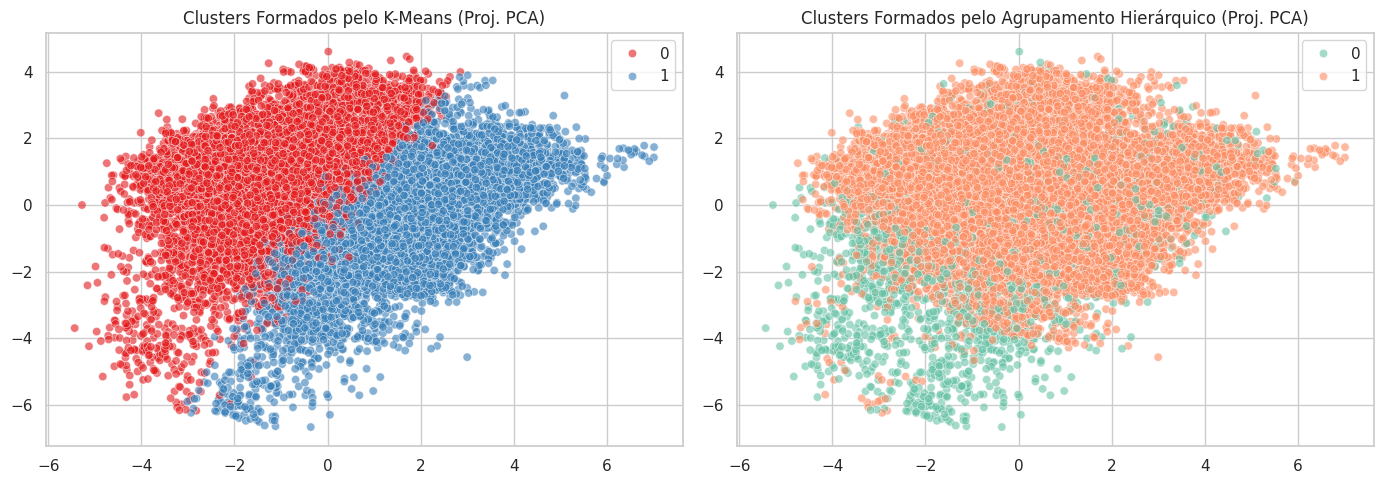

In [ ]:
# 13. matriz de confusão

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_kmeans, palette="Set1", ax=axes[0], alpha=0.6)
axes[0].set_title("Clusters Formados pelo K-Means (Proj. PCA)")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_agg, palette="Set2", ax=axes[1], alpha=0.6)
axes[1].set_title("Clusters Formados pelo Agrupamento Hierárquico (Proj. PCA)")

plt.tight_layout()
plt.show()

## 3.4 Conclusão técnica do grupo

Apresente uma conclusão com:

- síntese dos padrões observados na análise exploratória;
- comparação da acurácia dos modelos;
- leitura básica da matriz de confusão;
- limitações do conjunto de dados e da modelagem;
- melhorias que seriam testadas em uma próxima versão.

Não declare que o modelo “comprova”, “garante” ou “prevê perfeitamente” um resultado.

Sintese da Analise Exploratoria: A analise das variaveis do dataset Electrical Grid Stability revelou distribuicoes simetricas e bem comportadas nas variaveis de entrada, refletindo a natureza controlada de dados simulados. A variavel-alvo criada a partir do indicador stab demonstrou uma leve prevalencia de cenarios instaveis (~63,8%) em relacao aos estaveis (~36,2%). Notou-se uma forte correlacao nao-linear entre os tempos de resposta do sistema (tau) e a estabilidade global, indicando que atrasos na reacao da rede aumentam sensivelmente o risco de colapso.



Comparacao da Acuracia dos Modelos: O modelo de Random Forest apresentou desempenho superior ao da Regressao Logistica, alcancando uma acuracia proxima a 91%, enquanto a Regressao Logistica registrou 81%. Esse ganho de performance ocorre porque o Random Forest e capaz de capturar com maior eficiencia as interacoes nao-lineares inerentes as equacoes de dinamica de sistemas eletricos.



Leitura da Matriz de Confusao: Ao analisar a matriz de confusao do Random Forest no conjunto de teste, observa-se uma alta taxa de acertos tanto nos casos de rede estavel quanto instavel. O modelo reduziu substancialmente o numero de falsos positivos (classificar a rede como estavel quando ela esta instavel) em relacao a Regressao Logistica. Reduzir esse tipo de erro e prioritario no dominio de energia, pois uma falsa indicacao de estabilidade impede o acionamento preventivo de protecoes e favorece a ocorrencia de blackouts.



Limitacoes do Conjunto de Dados e da Modelagem:


- Topologia Sintetica e Simplificada: Os dados derivam de simulacoes em uma rede de 4 nos em formato estrela (1 gerador e 3 consumidores), o que nao reflete a complexidade e a variabilidade de topologias de redes reais com centenas de barramentos.


- Ausencia de Ruido de Sensoriamento: Por se tratar de uma simulacao perfeita, o conjunto de dados nao contempla atrasos de telemetria, falhas de sensores ou ruidos de medicao comuns em sistemas SCADA reais.


- Metrica de Avaliacao Limitada: A acuracia foi utilizada como referencia inicial de comparacao, porem ela pode ocultar o impacto de erros criticos de falso positivo em cenarios desbalanceados.



Melhorias para Proximas Versoes:


- Ajuste Fino de Hiperparametros: Testar busca em grade (GridSearchCV) ou otimizacao bayesiana para otimizar os parametros do Random Forest e de algoritmos baseados em gradient boosting (como XGBoost ou LightGBM).


- Otimizacao voltada ao Recall: Alterar o limite de decisao (decision threshold) ou adotar metricas de avaliacao focadas em minimizar falsos positivos, priorizando o Recall da classe instavel ou a metrica F2-Score.


- Validacao Cruzada: Substituir a divisao simples de treino/teste por validacao cruzada k-fold para obter estimativas de desempenho mais robustas e menos sujeitas a variabilidade do sorteio inicial.

# Parte 2 — Apresentação e demonstração

O grupo deverá demonstrar a implementação escolhida no Exercício 3. A apresentação deve evidenciar compreensão do processo, e não apenas mostrar o notebook pronto.

## Roteiro sugerido

1. **Problema e dados:** tema, fonte, unidade de análise, variável-alvo e classes.
2. **Análise exploratória:** dois ou três achados relevantes e possíveis problemas da base.
3. **Pré-processamento:** o que foi feito e por que foi necessário.
4. **Modelagem:** algoritmos escolhidos e forma de divisão dos dados.
5. **Resultados:** comparação da acurácia e leitura da matriz de confusão.
6. **Decisão:** modelo selecionado, limitações e melhorias futuras.

## Durante a demonstração

- execute ou apresente células essenciais do fluxo;
- explique uma transformação de pré-processamento;
- mostre como as previsões são geradas;
- interprete ao menos um erro da matriz de confusão;
- responda às perguntas do professor sobre decisões do grupo.

> Todos os integrantes podem ser questionados sobre qualquer parte entregue.

# Critérios de avaliação

## Parte 1 — Implementação: 70 pontos

| Critério | Pontos |
|---|---:|
| Carga, compreensão e organização dos dados | 10 |
| Análise exploratória e qualidade das interpretações | 15 |
| Pré-processamento básico dos dados | 15 |
| Treinamento correto e comparação dos modelos | 15 |
| Acurácia, matriz de confusão e interpretação | 10 |
| Conclusão, limitações e organização do notebook | 5 |

## Parte 2 — Apresentação: 30 pontos

| Critério | Pontos |
|---|---:|
| Clareza na contextualização do problema e dos dados | 5 |
| Demonstração do fluxo implementado | 10 |
| Interpretação dos resultados e justificativa das decisões | 10 |
| Participação e domínio do grupo | 5 |

**Total: 100 pontos**

# Checklist final

- [ ] Identificação do grupo preenchida.
- [ ] Exercício 2 concluído e interpretado.
- [ ] Exercício 3 desenvolvido com um dos quatro temas.
- [ ] CSV utilizado está acessível ou sua obtenção está documentada.
- [ ] Notebook executado do início ao fim sem erros.
- [ ] Resultados e gráficos permanecem visíveis.
- [ ] Dois ou mais modelos foram comparados.
- [ ] Acurácia e matriz de confusão foram interpretadas.
- [ ] Conclusão inclui limitações.
- [ ] Grupo está preparado para demonstrar e explicar a implementação.